# Correlation matrices

This notebook is separate from the rest of the code and does not change existing scripts or reports.

It produces three correlation matrices:

- technical and volume features
- macro data
- macro interactions


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "core").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

sns.set_theme(style="white", context="notebook")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


In [2]:
BASE_FEATURE_COLUMNS = [
    "mom_12_1",
    "mom_6_1",
    "mom_3_1",
    "tsmom_12",
    "tsmom_sign_12",
    "reversal_1m",
    "ma_gap_12m",
    "ma_crossover_6_12",
    "ma_signal_3_12",
    "vol_3m",
    "vol_12m",
    "vol_regime_3_12",
    "log_volume",
    "abnormal_log_volume",
]

MACRO_FEATURE_COLUMNS = [
    "macro_vix",
    "macro_epu",
    "macro_credit_spread",
    "macro_term_spread",
]

SUPERVISOR_MACRO_INTERACTION_COLUMNS = [
    "mom_12_1_x_macro_epu",
    "mom_12_1_x_macro_vix",
    "tsmom_12_x_macro_epu",
    "tsmom_12_x_macro_vix",
    "ma_gap_12m_x_macro_epu",
    "ma_crossover_6_12_x_macro_vix",
    "reversal_1m_x_macro_epu",
    "reversal_1m_x_macro_vix",
    "reversal_1m_x_macro_credit_spread",
    "abnormal_log_volume_x_macro_epu",
    "abnormal_log_volume_x_macro_vix",
    "log_volume_x_macro_credit_spread",
    "vol_regime_3_12_x_macro_vix",
    "vol_regime_3_12_x_macro_term_spread",
    "vol_12m_x_macro_credit_spread",
]


FEATURES_PATH = PROJECT_ROOT / "artifacts" / "features" / "features.parquet"
MACRO_PATH = PROJECT_ROOT / "artifacts" / "macro" / "macro_factors.parquet"

print(f"Feature input: {FEATURES_PATH}")
print(f"Macro input:   {MACRO_PATH}")


Feature input: /Users/rasmusmohrthuesen/Desktop/projekt_2/artifacts/features/features.parquet
Macro input:   /Users/rasmusmohrthuesen/Desktop/projekt_2/artifacts/macro/macro_factors.parquet


In [3]:
def month_key(values: pd.Series) -> pd.Series:
    return pd.to_datetime(values).dt.to_period("M")


def load_feature_frame() -> pd.DataFrame:
    if not FEATURES_PATH.exists():
        raise FileNotFoundError(f"Missing feature artifact: {FEATURES_PATH}")
    if not MACRO_PATH.exists():
        raise FileNotFoundError(f"Missing macro artifact: {MACRO_PATH}")

    features = pd.read_parquet(FEATURES_PATH).copy()
    macro = pd.read_parquet(MACRO_PATH).copy()

    features["date"] = pd.to_datetime(features["date"])
    macro["date"] = pd.to_datetime(macro["date"])

    missing_macro = [col for col in MACRO_FEATURE_COLUMNS if col not in features.columns]
    if missing_macro:
        features["month_key"] = month_key(features["date"])
        macro["month_key"] = month_key(macro["date"])
        macro_monthly = macro[["month_key", *MACRO_FEATURE_COLUMNS]].drop_duplicates("month_key")
        features = features.merge(macro_monthly, on="month_key", how="left")
        features = features.drop(columns=["month_key"])

    return features


df = load_feature_frame()
print(df.shape)
df.head()


(210000, 31)


,date,time_index,row_id,asset_id,ret_1m,volume_1m,mom_12_1,mom_6_1,mom_3_1,tsmom_12,tsmom_sign_12,reversal_1m,ma_gap_12m,ma_crossover_6_12,vol_3m,vol_12m,vol_regime_3_12,log_volume,log_volume_ma_12,abnormal_log_volume,has_asset_id,has_finite_return,cs_mom_12_1,target_ret_1m,target_available,history_count,feature_ready,macro_vix,macro_epu,macro_credit_spread,macro_term_spread
0,1989-12-29,0,0,11850.0,0.058201,194216.0,0.105609,0.081296,0.051428,1.035997,1.0,-0.040217,0.084174,0.026383,0.008926,0.029427,-0.696679,12.176731,12.525286,-0.348555,True,True,-0.705135,0.058201,True,120,True,NaN,103.796681,1.68,0.31
1,1989-12-29,0,1,12490.0,-0.035851,305779.0,-0.128010,-0.076071,-0.144077,-0.655400,-1.0,0.014115,-0.122714,-0.030456,0.035850,0.056383,-0.364168,12.585374,12.683541,-0.052920,True,True,-1.607279,-0.035851,True,120,True,NaN,103.796681,1.68,0.31
2,1989-12-29,0,2,12060.0,0.047903,292229.0,0.272392,0.029195,-0.032073,1.101904,1.0,-0.119639,0.179532,0.095059,0.078493,0.071361,0.099950,12.585296,12.599791,-0.014495,True,True,-0.061082,0.047903,True,120,True,NaN,103.796681,1.68,0.31
3,1989-12-29,0,3,10401.0,0.046857,231969.0,0.534016,0.261126,0.110176,2.252043,1.0,0.011299,0.184353,0.135362,0.079957,0.068452,0.168068,12.354363,12.848511,-0.494148,True,True,0.949211,0.046857,True,120,True,NaN,103.796681,1.68,0.31
4,1989-12-29,0,4,13901.0,-0.009587,397081.0,0.846626,0.256740,0.059155,4.794223,1.0,0.014535,0.206703,0.164549,0.029678,0.050160,-0.408331,12.585374,12.131042,0.760857,True,True,2.156391,-0.009587,True,120,True,NaN,103.796681,1.68,0.31


In [4]:
def add_macro_interactions(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out["mom_12_1_x_macro_epu"] = out["mom_12_1"] * out["macro_epu"]
    out["mom_12_1_x_macro_vix"] = out["mom_12_1"] * out["macro_vix"]
    out["tsmom_12_x_macro_epu"] = out["tsmom_12"] * out["macro_epu"]
    out["tsmom_12_x_macro_vix"] = out["tsmom_12"] * out["macro_vix"]
    out["ma_gap_12m_x_macro_epu"] = out["ma_gap_12m"] * out["macro_epu"]
    out["ma_crossover_6_12_x_macro_vix"] = out["ma_crossover_6_12"] * out["macro_vix"]
    out["reversal_1m_x_macro_epu"] = out["reversal_1m"] * out["macro_epu"]
    out["reversal_1m_x_macro_vix"] = out["reversal_1m"] * out["macro_vix"]
    out["reversal_1m_x_macro_credit_spread"] = out["reversal_1m"] * out["macro_credit_spread"]
    out["abnormal_log_volume_x_macro_epu"] = out["abnormal_log_volume"] * out["macro_epu"]
    out["abnormal_log_volume_x_macro_vix"] = out["abnormal_log_volume"] * out["macro_vix"]
    out["log_volume_x_macro_credit_spread"] = out["log_volume"] * out["macro_credit_spread"]
    out["vol_regime_3_12_x_macro_vix"] = out["vol_regime_3_12"] * out["macro_vix"]
    out["vol_regime_3_12_x_macro_term_spread"] = out["vol_regime_3_12"] * out["macro_term_spread"]
    out["vol_12m_x_macro_credit_spread"] = out["vol_12m"] * out["macro_credit_spread"]
    return out


required_for_interactions = sorted(
    {
        "mom_12_1",
        "tsmom_12",
        "ma_gap_12m",
        "ma_crossover_6_12",
        "reversal_1m",
        "abnormal_log_volume",
        "log_volume",
        "vol_regime_3_12",
        "vol_12m",
        *MACRO_FEATURE_COLUMNS,
    }
)
missing_for_interactions = [col for col in required_for_interactions if col not in df.columns]
if missing_for_interactions:
    raise ValueError(f"Cannot build macro interactions. Missing columns: {missing_for_interactions}")

df = add_macro_interactions(df)

technical_volume_cols = [col for col in BASE_FEATURE_COLUMNS if col in df.columns]

macro_cols = [col for col in MACRO_FEATURE_COLUMNS if col in df.columns]
interaction_cols = [col for col in SUPERVISOR_MACRO_INTERACTION_COLUMNS if col in df.columns]

missing_baseline_cols = [col for col in BASE_FEATURE_COLUMNS if col not in df.columns]
print("Technical/volume columns:", len(technical_volume_cols), technical_volume_cols)
print("Macro columns:", len(macro_cols), macro_cols)
print("Interaction columns:", len(interaction_cols), interaction_cols)
print("Missing canonical baseline columns in current artifact:", missing_baseline_cols)


Technical/volume columns: 13 ['mom_12_1', 'mom_6_1', 'mom_3_1', 'tsmom_12', 'tsmom_sign_12', 'reversal_1m', 'ma_gap_12m', 'ma_crossover_6_12', 'vol_3m', 'vol_12m', 'vol_regime_3_12', 'log_volume', 'abnormal_log_volume']
Macro columns: 4 ['macro_vix', 'macro_epu', 'macro_credit_spread', 'macro_term_spread']
Interaction columns: 15 ['mom_12_1_x_macro_epu', 'mom_12_1_x_macro_vix', 'tsmom_12_x_macro_epu', 'tsmom_12_x_macro_vix', 'ma_gap_12m_x_macro_epu', 'ma_crossover_6_12_x_macro_vix', 'reversal_1m_x_macro_epu', 'reversal_1m_x_macro_vix', 'reversal_1m_x_macro_credit_spread', 'abnormal_log_volume_x_macro_epu', 'abnormal_log_volume_x_macro_vix', 'log_volume_x_macro_credit_spread', 'vol_regime_3_12_x_macro_vix', 'vol_regime_3_12_x_macro_term_spread', 'vol_12m_x_macro_credit_spread']
Missing canonical baseline columns in current artifact: ['ma_signal_3_12']


## Descriptive statistics

This table can be used as the basis for a thesis table with mean, median, and distributional measures for the core factors. Technical/volume factors are computed from stock-month observations, while macro factors are computed from unique months.


In [5]:
def descriptive_stats(frame: pd.DataFrame, columns: list[str]) -> pd.DataFrame:
    clean = frame[columns].replace([np.inf, -np.inf], np.nan)
    stats = pd.DataFrame(
        {
            "Mean": clean.mean(),
            "Median": clean.median(),
            "Std. Dev.": clean.std(),
            "P5": clean.quantile(0.05),
            "P95": clean.quantile(0.95),
        }
    )
    return stats.reset_index(names="Variable")


core_technical_cols = [col for col in BASE_FEATURE_COLUMNS if col in df.columns]
technical_stats = descriptive_stats(df, core_technical_cols)

macro_monthly = df[["date", *macro_cols]].drop_duplicates("date")
macro_stats = descriptive_stats(macro_monthly, macro_cols)

core_factor_stats = pd.concat([technical_stats, macro_stats], ignore_index=True)
print(f"Core factor table rows: {len(core_factor_stats)}")
core_factor_stats.round(4)


Core factor table rows: 17


,Variable,Mean,Median,Std. Dev.,P5,P95
0,mom_12_1,0.1655,0.1313,0.3457,-0.2995,0.7342
1,mom_6_1,0.0723,0.0615,0.2066,-0.2323,0.4121
2,mom_3_1,0.0288,0.0260,0.1251,-0.1647,0.2314
3,tsmom_12,0.7141,0.5613,1.1570,-0.8821,2.8433
4,tsmom_sign_12,0.4067,1.0000,0.9136,-1.0000,1.0000
5,reversal_1m,-0.0144,-0.0131,0.0877,-0.1555,0.1220
6,ma_gap_12m,0.0487,0.0616,0.1595,-0.2212,0.2783
7,ma_crossover_6_12,0.0306,0.0349,0.0846,-0.1097,0.1601
8,vol_3m,0.0738,0.0612,0.0534,0.0149,0.1747
9,vol_12m,0.0819,0.0726,0.0409,0.0362,0.1590


In [6]:
def corr_matrix(frame: pd.DataFrame, columns: list[str], method: str = "pearson") -> pd.DataFrame:
    clean = frame[columns].replace([np.inf, -np.inf], np.nan)
    return clean.corr(method=method)


def plot_corr(corr: pd.DataFrame, title: str, figsize=None) -> None:
    if figsize is None:
        size = max(7, min(18, 0.65 * len(corr.columns)))
        figsize = (size, size)


    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 8},
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        square=True,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8, "label": "Pearson correlation"},
        ax=ax,
    )
    ax.set_title(title, pad=14)
    ax.tick_params(axis="x", labelrotation=55, labelsize=9)
    ax.tick_params(axis="y", labelrotation=0, labelsize=10)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")
        label.set_rotation_mode("anchor")
    plt.tight_layout()
    plt.show()


def cross_corr_matrix(frame: pd.DataFrame, row_columns: list[str], col_columns: list[str]) -> pd.DataFrame:
    clean = frame[[*row_columns, *col_columns]].replace([np.inf, -np.inf], np.nan)
    corr = clean.corr(method="pearson")
    return corr.loc[row_columns, col_columns]


def plot_cross_corr(corr: pd.DataFrame, title: str, figsize=None) -> None:
    if figsize is None:
        figsize = (max(9, 0.75 * len(corr.columns)), max(3.5, 0.55 * len(corr.index)))

    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(
        corr,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 8},
        cmap="coolwarm",
        vmin=-1,
        vmax=1,
        center=0,
        linewidths=0.5,
        cbar_kws={"shrink": 0.8, "label": "Pearson correlation"},
        ax=ax,
    )
    ax.set_title(title, pad=14)
    ax.tick_params(axis="x", labelrotation=55, labelsize=9)
    ax.tick_params(axis="y", labelrotation=0, labelsize=10)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")
        label.set_rotation_mode("anchor")
    plt.tight_layout()
    plt.show()


## 1. Technical and volume features


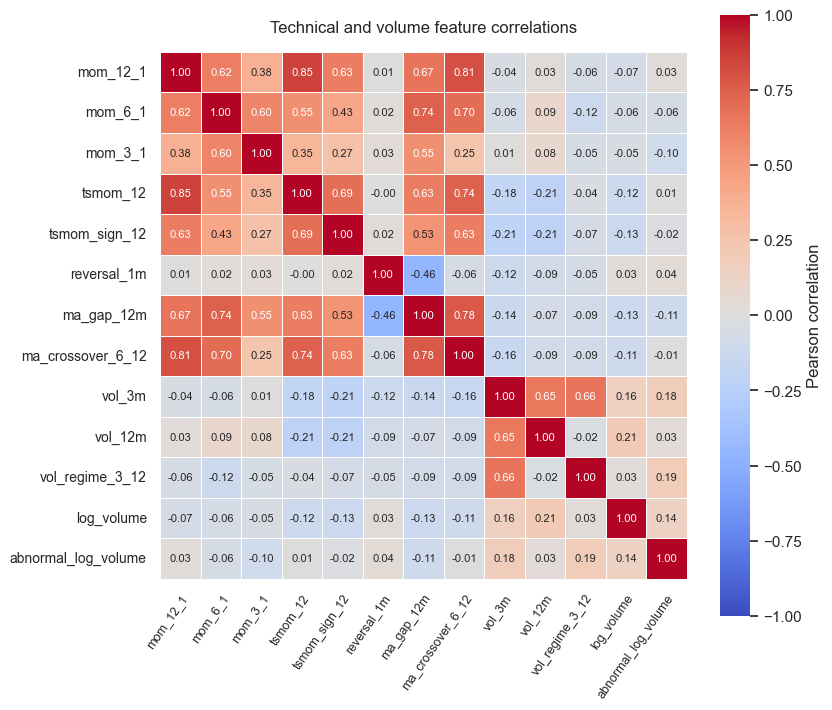

,mom_12_1,mom_6_1,mom_3_1,tsmom_12,tsmom_sign_12,reversal_1m,ma_gap_12m,ma_crossover_6_12,vol_3m,vol_12m,vol_regime_3_12,log_volume,abnormal_log_volume
mom_12_1,1.000,0.623,0.376,0.852,0.627,0.009,0.665,0.812,-0.041,0.025,-0.056,-0.069,0.031
mom_6_1,0.623,1.000,0.595,0.550,0.432,0.020,0.745,0.698,-0.061,0.089,-0.118,-0.058,-0.061
mom_3_1,0.376,0.595,1.000,0.346,0.272,0.034,0.551,0.249,0.008,0.082,-0.051,-0.046,-0.096
tsmom_12,0.852,0.550,0.346,1.000,0.689,-0.001,0.629,0.744,-0.182,-0.214,-0.037,-0.116,0.008
tsmom_sign_12,0.627,0.432,0.272,0.689,1.000,0.024,0.529,0.629,-0.205,-0.213,-0.070,-0.128,-0.022
reversal_1m,0.009,0.020,0.034,-0.001,0.024,1.000,-0.455,-0.055,-0.123,-0.088,-0.055,0.029,0.043
ma_gap_12m,0.665,0.745,0.551,0.629,0.529,-0.455,1.000,0.779,-0.140,-0.070,-0.090,-0.131,-0.109
ma_crossover_6_12,0.812,0.698,0.249,0.744,0.629,-0.055,0.779,1.000,-0.156,-0.087,-0.090,-0.109,-0.014
vol_3m,-0.041,-0.061,0.008,-0.182,-0.205,-0.123,-0.140,-0.156,1.000,0.650,0.665,0.163,0.179
vol_12m,0.025,0.089,0.082,-0.214,-0.213,-0.088,-0.070,-0.087,0.650,1.000,-0.024,0.211,0.034


In [7]:
technical_volume_corr = corr_matrix(df, technical_volume_cols)
plot_corr(technical_volume_corr, "Technical and volume feature correlations")
technical_volume_corr.round(3)


In [10]:
def off_diagonal_abs_corr_summary(corr: pd.DataFrame) -> pd.DataFrame:
    mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
    values = corr.where(mask).stack().abs()
    return pd.DataFrame(
        {
            "Mean absolute off-diagonal correlation": [values.mean()],
            "Median absolute off-diagonal correlation": [values.median()],
            "Number of pairs": [len(values)],
        }
    )


technical_volume_offdiag_summary = off_diagonal_abs_corr_summary(technical_volume_corr)
technical_volume_offdiag_summary.round(3)


,Mean absolute off-diagonal correlation,Median absolute off-diagonal correlation,Number of pairs
0,0.24,0.117,78


## 2. Macro data


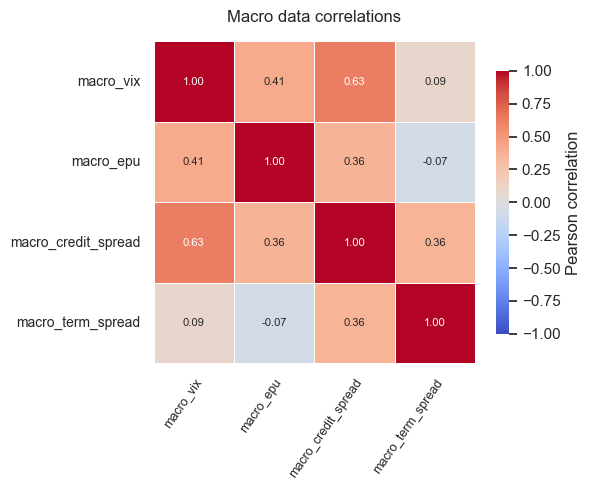

,macro_vix,macro_epu,macro_credit_spread,macro_term_spread
macro_vix,1.000,0.410,0.628,0.088
macro_epu,0.410,1.000,0.360,-0.071
macro_credit_spread,0.628,0.360,1.000,0.359
macro_term_spread,0.088,-0.071,0.359,1.000


In [122]:
macro_corr = corr_matrix(df.drop_duplicates("date"), macro_cols)
plot_corr(macro_corr, "Macro data correlations", figsize=(6, 5))
macro_corr.round(3)


## 3. Macro state variables vs. technical/volume features

Technical/volume features are first aggregated to monthly cross-sectional means, so each month receives one observation against the macro state variables.


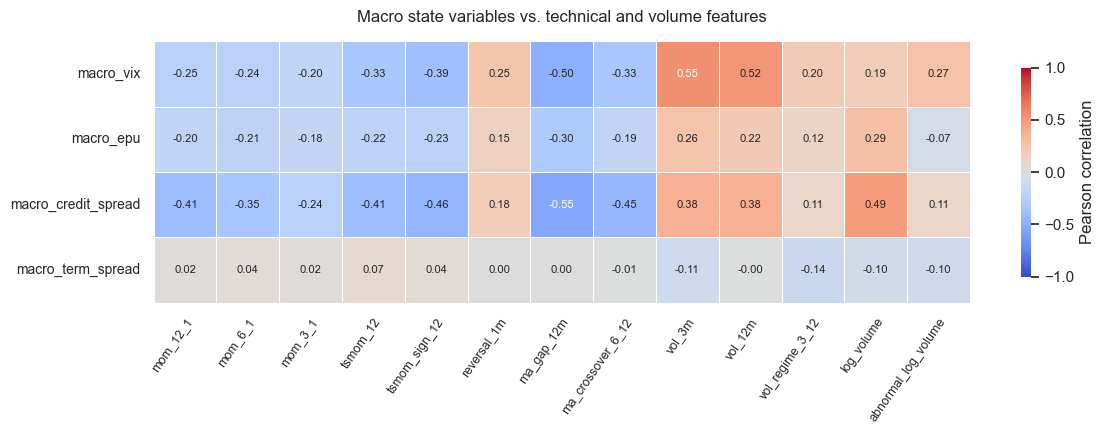

,mom_12_1,mom_6_1,mom_3_1,tsmom_12,tsmom_sign_12,reversal_1m,ma_gap_12m,ma_crossover_6_12,vol_3m,vol_12m,vol_regime_3_12,log_volume,abnormal_log_volume
macro_vix,-0.246,-0.238,-0.198,-0.330,-0.388,0.245,-0.497,-0.333,0.547,0.523,0.198,0.188,0.269
macro_epu,-0.197,-0.213,-0.177,-0.219,-0.228,0.152,-0.304,-0.193,0.263,0.216,0.123,0.288,-0.066
macro_credit_spread,-0.407,-0.347,-0.243,-0.408,-0.457,0.182,-0.553,-0.451,0.380,0.376,0.106,0.485,0.106
macro_term_spread,0.019,0.037,0.022,0.068,0.043,0.001,0.004,-0.007,-0.114,-0.001,-0.140,-0.098,-0.103


In [123]:
monthly_technical = (
    df.groupby("date", observed=True)[technical_volume_cols]
    .mean()
    .reset_index()
)
macro_monthly = df[["date", *macro_cols]].drop_duplicates("date")
macro_vs_technical_frame = macro_monthly.merge(monthly_technical, on="date", how="inner")

macro_vs_technical_corr = cross_corr_matrix(
    macro_vs_technical_frame,
    row_columns=macro_cols,
    col_columns=technical_volume_cols,
)

plot_cross_corr(
    macro_vs_technical_corr,
    "Macro state variables vs. technical and volume features",
    figsize=(12, 4.5),
)
macro_vs_technical_corr.round(3)


## 4. Macro interactions


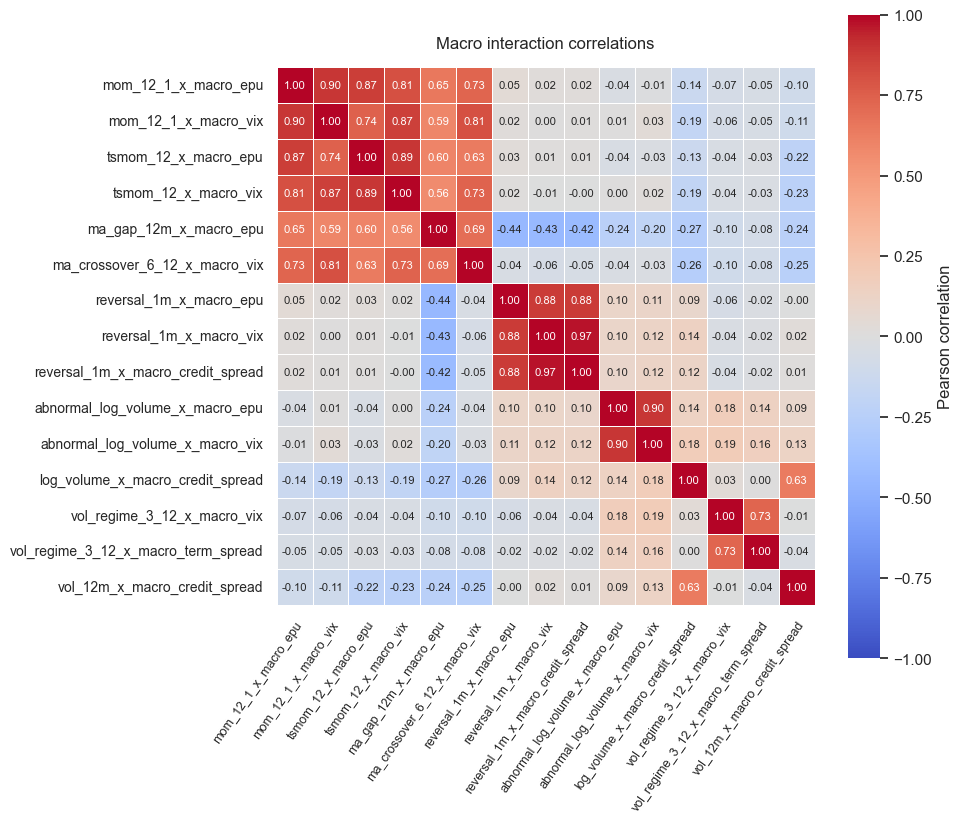

,mom_12_1_x_macro_epu,mom_12_1_x_macro_vix,tsmom_12_x_macro_epu,tsmom_12_x_macro_vix,ma_gap_12m_x_macro_epu,ma_crossover_6_12_x_macro_vix,reversal_1m_x_macro_epu,reversal_1m_x_macro_vix,reversal_1m_x_macro_credit_spread,abnormal_log_volume_x_macro_epu,abnormal_log_volume_x_macro_vix,log_volume_x_macro_credit_spread,vol_regime_3_12_x_macro_vix,vol_regime_3_12_x_macro_term_spread,vol_12m_x_macro_credit_spread
mom_12_1_x_macro_epu,1.000,0.896,0.874,0.809,0.652,0.728,0.045,0.020,0.023,-0.039,-0.014,-0.137,-0.069,-0.049,-0.097
mom_12_1_x_macro_vix,0.896,1.000,0.743,0.865,0.587,0.805,0.023,0.001,0.008,0.007,0.032,-0.185,-0.064,-0.050,-0.109
tsmom_12_x_macro_epu,0.874,0.743,1.000,0.892,0.601,0.635,0.026,0.011,0.010,-0.042,-0.028,-0.132,-0.044,-0.027,-0.216
tsmom_12_x_macro_vix,0.809,0.865,0.892,1.000,0.563,0.735,0.015,-0.006,-0.000,0.001,0.020,-0.190,-0.044,-0.032,-0.231
ma_gap_12m_x_macro_epu,0.652,0.587,0.601,0.563,1.000,0.695,-0.444,-0.433,-0.423,-0.237,-0.199,-0.273,-0.100,-0.077,-0.242
ma_crossover_6_12_x_macro_vix,0.728,0.805,0.635,0.735,0.695,1.000,-0.043,-0.058,-0.049,-0.036,-0.030,-0.262,-0.101,-0.084,-0.247
reversal_1m_x_macro_epu,0.045,0.023,0.026,0.015,-0.444,-0.043,1.000,0.882,0.875,0.104,0.111,0.093,-0.057,-0.024,-0.003
reversal_1m_x_macro_vix,0.020,0.001,0.011,-0.006,-0.433,-0.058,0.882,1.000,0.969,0.104,0.125,0.142,-0.037,-0.016,0.024
reversal_1m_x_macro_credit_spread,0.023,0.008,0.010,-0.000,-0.423,-0.049,0.875,0.969,1.000,0.098,0.121,0.123,-0.044,-0.021,0.013
abnormal_log_volume_x_macro_epu,-0.039,0.007,-0.042,0.001,-0.237,-0.036,0.104,0.104,0.098,1.000,0.895,0.136,0.179,0.144,0.086


In [124]:
interaction_corr = corr_matrix(df, interaction_cols)
plot_corr(interaction_corr, "Macro interaction correlations")
interaction_corr.round(3)


## Optional: strongest absolute correlations


In [125]:
def strongest_pairs(corr: pd.DataFrame, n: int = 15) -> pd.DataFrame:
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    pairs = (
        upper.stack()
        .rename("corr")
        .reset_index()
        .rename(columns={"level_0": "feature_a", "level_1": "feature_b"})
    )
    pairs["abs_corr"] = pairs["corr"].abs()
    return pairs.sort_values("abs_corr", ascending=False).head(n).reset_index(drop=True)


display(strongest_pairs(technical_volume_corr, 15))
display(strongest_pairs(macro_corr, 15))
display(strongest_pairs(interaction_corr, 15))


,feature_a,feature_b,corr,abs_corr
0,mom_12_1,tsmom_12,0.851953,0.851953
1,mom_12_1,ma_crossover_6_12,0.811543,0.811543
2,ma_gap_12m,ma_crossover_6_12,0.779481,0.779481
3,mom_6_1,ma_gap_12m,0.744929,0.744929
4,tsmom_12,ma_crossover_6_12,0.744231,0.744231
5,mom_6_1,ma_crossover_6_12,0.698015,0.698015
6,tsmom_12,tsmom_sign_12,0.689057,0.689057
7,mom_12_1,ma_gap_12m,0.665269,0.665269
8,vol_3m,vol_regime_3_12,0.664810,0.664810
9,vol_3m,vol_12m,0.650085,0.650085


,feature_a,feature_b,corr,abs_corr
0,macro_vix,macro_credit_spread,0.628230,0.628230
1,macro_vix,macro_epu,0.409732,0.409732
2,macro_epu,macro_credit_spread,0.359502,0.359502
3,macro_credit_spread,macro_term_spread,0.358809,0.358809
4,macro_vix,macro_term_spread,0.088127,0.088127
5,macro_epu,macro_term_spread,-0.071062,0.071062


,feature_a,feature_b,corr,abs_corr
0,reversal_1m_x_macro_vix,reversal_1m_x_macro_credit_spread,0.968795,0.968795
1,mom_12_1_x_macro_epu,mom_12_1_x_macro_vix,0.895992,0.895992
2,abnormal_log_volume_x_macro_epu,abnormal_log_volume_x_macro_vix,0.895444,0.895444
3,tsmom_12_x_macro_epu,tsmom_12_x_macro_vix,0.891674,0.891674
4,reversal_1m_x_macro_epu,reversal_1m_x_macro_vix,0.882256,0.882256
5,reversal_1m_x_macro_epu,reversal_1m_x_macro_credit_spread,0.875469,0.875469
6,mom_12_1_x_macro_epu,tsmom_12_x_macro_epu,0.873526,0.873526
7,mom_12_1_x_macro_vix,tsmom_12_x_macro_vix,0.865383,0.865383
8,mom_12_1_x_macro_epu,tsmom_12_x_macro_vix,0.809260,0.809260
9,mom_12_1_x_macro_vix,ma_crossover_6_12_x_macro_vix,0.805342,0.805342


## Out-of-sample stock-level predictive performance

OOS R² is computed cross-sectionally relative to a month-specific mean-return benchmark.


In [126]:
TWO_STEP_PREDICTION_PATHS = {
    "Elastic Net": PROJECT_ROOT
    / "artifacts"
    / "macroext_twostep_elasticnet_supervisor_constrained_final_prema_v1"
    / "twostep"
    / "predictions.parquet",
    "Random Forest": PROJECT_ROOT
    / "artifacts"
    / "macroext_twostep_random_forest_supervisor_constrained_final_prema_v1"
    / "twostep"
    / "predictions.parquet",
}


def monthly_spearman_ic(group: pd.DataFrame) -> float:
    if group["prediction"].nunique(dropna=True) < 2:
        return np.nan
    if group["target_ret_1m"].nunique(dropna=True) < 2:
        return np.nan
    return group["prediction"].corr(group["target_ret_1m"], method="spearman")


def stock_level_predictive_performance(model: str, path: Path):
    predictions = pd.read_parquet(path)
    work = predictions.dropna(subset=["target_ret_1m", "prediction"]).copy()

    month_mean = work.groupby("date", observed=True)["target_ret_1m"].transform("mean")
    squared_error = ((work["target_ret_1m"] - work["prediction"]) ** 2).sum()
    benchmark_error = ((work["target_ret_1m"] - month_mean) ** 2).sum()
    oos_r2 = 1.0 - (squared_error / benchmark_error)

    monthly_ic = (
        work.groupby("date", observed=True)[["prediction", "target_ret_1m"]]
        .apply(monthly_spearman_ic)
        .dropna()
    )

    return {
        "Model": model,
        "OOS R²": oos_r2,
        "Mean monthly Spearman IC": monthly_ic.mean(),
        "Std. monthly Spearman IC": monthly_ic.std(),
        "IC hit rate (%)": (monthly_ic > 0).mean() * 100,
    }


predictive_performance = pd.DataFrame(
    [stock_level_predictive_performance(model, path) for model, path in TWO_STEP_PREDICTION_PATHS.items()]
)

predictive_performance.round(
    {
        "OOS R²": 3,
        "Mean monthly Spearman IC": 3,
        "Std. monthly Spearman IC": 3,
        "IC hit rate (%)": 1,
    }
)


,Model,OOS R²,Mean monthly Spearman IC,Std. monthly Spearman IC,IC hit rate (%)
0,Elastic Net,-0.287,-0.003,0.179,43.7
1,Random Forest,-0.429,0.008,0.166,50.8
